# Time Cell Minimal Loop (Train → Evaluate → Plot)
This notebook is **self-contained** (no `torchvision` dependency) and is designed to run a minimal closed-loop pipeline:
1) Load variable-length trajectory folders (pkl + images)
2) Train a Visual-Temporal LSTM model
3) Evaluate (MSE/R²) and plot predicted vs GT trajectory

**You only need to set `DATA_ROOT_DIR` to your dataset path.**

In [14]:
# === 0) Imports & Reproducibility ===
%load_ext autoreload
%autoreload 2

import os, re, pickle, math, random
from glob import glob
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
N_CELLS_ANALYZE = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cuda


In [15]:
# === 1) Config (EDIT THIS) ===
DATA_ROOT_DIR = "/media/zhen/Data/Datasets/nomad_data/go_stanford"  # <-- CHANGE ME
SAVE_DIR = "./eval_results_minimal"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 8
EPOCHS = 50           # start small for sanity; increase later (e.g., 50-200)
LR = 1e-4
HIDDEN_DIM = 128
VISUAL_DIM = 256

USE_YAW = True
MIN_LEN = 3
IMG_SIZE = (64, 64)

CKPT_PATH = os.path.join(SAVE_DIR, "best_timecell_model.pth")


In [16]:
# === 2) Dataset (variable-length trajectory folders: traj_data.pkl + images) ===

def sort_key(path: str) -> int:
    nums = re.findall(r"\d+", os.path.basename(path))
    return int(nums[-1]) if nums else 0

def pil_to_tensor(img: Image.Image) -> torch.Tensor:
    """Convert PIL RGB image to torch float tensor [3,H,W] in [0,1] without torchvision."""
    arr = np.asarray(img, dtype=np.float32) / 255.0  # [H,W,3]
    if arr.ndim == 2:
        arr = np.repeat(arr[..., None], 3, axis=2)
    arr = np.transpose(arr, (2, 0, 1))              # [3,H,W]
    return torch.from_numpy(arr)

class VariableLengthTrajectoryDataset(Dataset):
    """
    Each trajectory is a folder containing:
      - traj_data.pkl with keys: 'position' (Tx2 or Tx3), 'yaw' (T,)
      - images: *.jpg or *.png directly under the folder
    Target: last position (pos[-1])
    Features per step: [pos, yaw] (if USE_YAW) else [pos]
    """
    def __init__(self, root_dir: str, use_yaw: bool=True, min_len: int=3, img_size=(64,64)):
        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Dataset root directory not found: {root_dir}")
        self.root_dir = root_dir
        self.use_yaw = use_yaw
        self.min_len = min_len
        self.img_size = img_size

        self.trajectories = sorted([
            os.path.join(root_dir, d)
            for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])
        if len(self.trajectories) == 0:
            raise ValueError(f"No trajectory folders found under: {root_dir}")
        print(f"✅ Found {len(self.trajectories)} trajectories in {root_dir}")

        # infer dims from first valid sample
        self.target_dim = None
        self.input_feature_dim = None
        for tp in self.trajectories[:10]:
            pkl_path = os.path.join(tp, "traj_data.pkl")
            if not os.path.exists(pkl_path):
                continue
            with open(pkl_path, "rb") as f:
                data = pickle.load(f)
            pos = np.asarray(data.get("position", []), dtype=np.float32)
            yaw = np.asarray(data.get("yaw", []), dtype=np.float32)
            if pos.ndim != 2 or len(pos) < self.min_len:
                continue
            self.target_dim = pos.shape[1]
            self.input_feature_dim = self.target_dim + (1 if (self.use_yaw and yaw.size > 0) else 0)
            break
        if self.target_dim is None:
            raise RuntimeError("Failed to infer target_dim/input_feature_dim. Check your pkl files.")
        print(f"Detected target_dim (position) = {self.target_dim}")
        print(f"Detected input_feature_dim (pos + yaw={self.use_yaw}) = {self.input_feature_dim}")

    def __len__(self):
        return len(self.trajectories)

    def _load_pkl(self, traj_path):
        pkl_path = os.path.join(traj_path, "traj_data.pkl")
        if not os.path.exists(pkl_path):
            return None
        with open(pkl_path, "rb") as f:
            data = pickle.load(f)
        pos = np.asarray(data["position"], dtype=np.float32)
        yaw = np.asarray(data.get("yaw", []), dtype=np.float32)
        return pos, yaw

    def _load_images(self, traj_path):
        img_files = sorted(glob(os.path.join(traj_path, "*.jpg")), key=sort_key)
        if not img_files:
            img_files = sorted(glob(os.path.join(traj_path, "*.png")), key=sort_key)
        imgs = []
        for fp in img_files:
            img = Image.open(fp).convert("RGB").resize(self.img_size)
            imgs.append(pil_to_tensor(img))
        if len(imgs) == 0:
            return None
        return torch.stack(imgs, dim=0)  # [T,3,H,W]

    def __getitem__(self, idx):
        traj_path = self.trajectories[idx]
        loaded = self._load_pkl(traj_path)
        if loaded is None:
            return None
        pos, yaw = loaded
        imgs = self._load_images(traj_path)
        if imgs is None:
            return None

        T = min(len(pos), imgs.shape[0])
        if T < self.min_len:
            return None

        pos = pos[:T]
        imgs = imgs[:T]
        if self.use_yaw and yaw.size > 0:
            yaw = yaw[:T].reshape(T, 1).astype(np.float32)
            feats = np.concatenate([pos, yaw], axis=1)  # [T, Dpos+1]
        else:
            feats = pos  # [T, Dpos]

        feats = torch.from_numpy(feats).float()
        target = torch.from_numpy(pos[-1]).float()     # [Dpos]
        return feats, imgs, target

def collate_variable_length(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None, None, None, None
    feats, imgs, targets = zip(*batch)
    lengths = [f.shape[0] for f in feats]
    max_len = max(lengths)

    B = len(batch)
    feat_dim = feats[0].shape[1]
    C, H, W = imgs[0].shape[1], imgs[0].shape[2], imgs[0].shape[3]

    feats_pad = torch.zeros(B, max_len, feat_dim, dtype=torch.float32)
    imgs_pad  = torch.zeros(B, max_len, C, H, W, dtype=torch.float32)
    mask      = torch.zeros(B, max_len, dtype=torch.bool)

    for i, (f, im) in enumerate(zip(feats, imgs)):
        L = f.shape[0]
        feats_pad[i, :L] = f
        imgs_pad[i, :L] = im
        mask[i, :L] = True

    targets = torch.stack(targets, dim=0)
    return feats_pad, imgs_pad, targets, mask

# build loader
dataset = VariableLengthTrajectoryDataset(DATA_ROOT_DIR, use_yaw=USE_YAW, min_len=MIN_LEN, img_size=IMG_SIZE)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_variable_length)

# sanity: peek one batch
batch = next(iter(loader))
feats, imgs, targets, mask = batch
print("feats:", feats.shape, "imgs:", imgs.shape, "targets:", targets.shape, "mask:", mask.shape, "mask_valid:", mask.sum().item())


✅ Found 3696 trajectories in /media/zhen/Data/Datasets/nomad_data/go_stanford
Detected target_dim (position) = 2
Detected input_feature_dim (pos + yaw=True) = 3
feats: torch.Size([5, 47, 3]) imgs: torch.Size([5, 47, 3, 64, 64]) targets: torch.Size([5, 2]) mask: torch.Size([5, 47]) mask_valid: 149


/tmp/ipykernel_1237963/3220069749.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)
/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


In [17]:
# === 3) Model (VisualTemporalNet without torchvision) ===

class VisualTemporalNet(nn.Module):
    def __init__(self, feature_dim: int, hidden_dim: int, visual_dim: int, output_dim: int):
        super().__init__()
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.visual_dim = visual_dim
        self.output_dim = output_dim

        # CNN encoder (expects 64x64)
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, visual_dim), nn.ReLU()
        )

        # LSTM consumes concatenated [feats, visual]
        self.lstm = nn.LSTM(input_size=feature_dim + visual_dim, hidden_size=hidden_dim,
                            num_layers=1, batch_first=True)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, feats, imgs, mask):
        # feats: [B,T,F], imgs: [B,T,3,H,W], mask: [B,T]
        B, T, _, H, W = imgs.shape
        imgs_flat = imgs.view(B*T, 3, H, W)
        v = self.cnn(imgs_flat).view(B, T, self.visual_dim)  # [B,T,V]

        x = torch.cat([feats, v], dim=-1)  # [B,T,F+V]

        lengths = mask.sum(dim=1).long().cpu()  # [B]
        # pack for variable-length
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=T)  # [B,T,H]

        # take last valid step per sequence
        idx = (lengths - 1).clamp(min=0).to(out.device)  # [B]
        last = out[torch.arange(B, device=out.device), idx]  # [B,H]
        pred = self.fc(last)  # [B,output_dim]
        return pred, out  # return full LSTM outputs for time-cell analyses later

model = VisualTemporalNet(
    feature_dim=dataset.input_feature_dim,
    hidden_dim=HIDDEN_DIM,
    visual_dim=VISUAL_DIM,
    output_dim=dataset.target_dim
).to(device)

# forward sanity
feats, imgs, targets, mask = next(iter(loader))
feats, imgs, targets, mask = feats.to(device), imgs.to(device), targets.to(device), mask.to(device)
pred, lstm_out = model(feats, imgs, mask)
print("pred:", pred.shape, "targets:", targets.shape, "lstm_out:", lstm_out.shape)
assert pred.shape == targets.shape, "❌ pred.shape must match targets.shape"


/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


pred: torch.Size([6, 2]) targets: torch.Size([6, 2]) lstm_out: torch.Size([6, 201, 128])


In [18]:
# === 4) Train (minimal) ===

def train_minimal(model, loader, device, epochs=20, lr=1e-4, ckpt_path=CKPT_PATH):
    model.to(device)
    loss_fn = nn.SmoothL1Loss()
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    best = float("inf")

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0
        n = 0
        for batch in loader:
            feats, imgs, targets, mask = batch
            if feats is None:
                continue
            feats, imgs, targets, mask = feats.to(device), imgs.to(device), targets.to(device), mask.to(device)

            optim.zero_grad(set_to_none=True)
            pred, _ = model(feats, imgs, mask)

            loss = loss_fn(pred, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optim.step()

            total += loss.item()
            n += 1

        avg = total / max(n, 1)
        print(f"Epoch {ep}/{epochs} | loss={avg:.6f}")

        if avg < best:
            best = avg
            torch.save(model.state_dict(), ckpt_path)
            print(f"✅ New best saved: {ckpt_path} (loss={best:.6f})")

    return ckpt_path

ckpt = train_minimal(model, loader, device, epochs=EPOCHS, lr=LR, ckpt_path=CKPT_PATH)


/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


Epoch 1/50 | loss=12.217257
✅ New best saved: ./eval_results_minimal/best_timecell_model.pth (loss=12.217257)


KeyboardInterrupt: 

/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


Eval | MSE=181.499115 | R2=0.5452


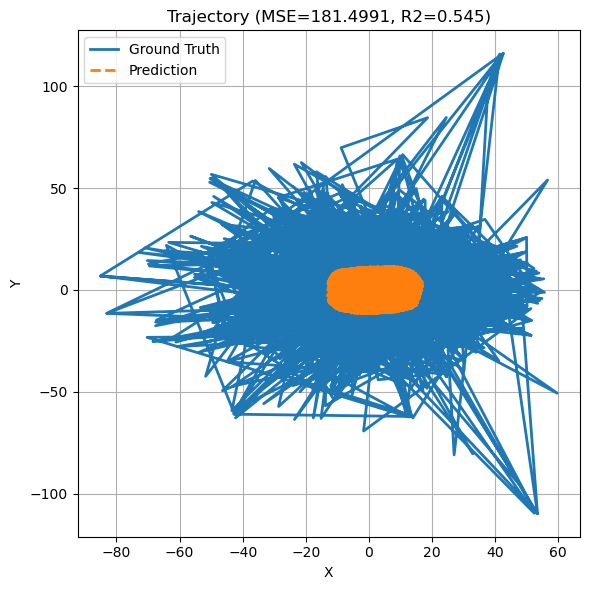

Saved plot: ./eval_results_minimal/timecell_minimal_traj.png


In [ ]:
# === 5) Evaluate + Plot (minimal loop output) ===

@torch.no_grad()
def evaluate_and_plot(model, loader, device, ckpt_path, save_dir=SAVE_DIR, prefix="timecell"):
    os.makedirs(save_dir, exist_ok=True)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.to(device)
    model.eval()

    preds_all, targets_all = [], []
    for batch in loader:
        feats, imgs, targets, mask = batch
        if feats is None:
            continue
        feats, imgs, targets, mask = feats.to(device), imgs.to(device), targets.to(device), mask.to(device)
        pred, _ = model(feats, imgs, mask)
        preds_all.append(pred.detach().cpu().numpy())
        targets_all.append(targets.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all, axis=0)
    targets_all = np.concatenate(targets_all, axis=0)

    mse = mean_squared_error(targets_all, preds_all)
    r2 = r2_score(targets_all, preds_all)
    print(f"Eval | MSE={mse:.6f} | R2={r2:.4f}")

    np.save(os.path.join(save_dir, f"{prefix}_preds.npy"), preds_all)
    np.save(os.path.join(save_dir, f"{prefix}_targets.npy"), targets_all)

    # Trajectory plot (assumes first 2 dims are x,y)
    if preds_all.shape[1] >= 2 and targets_all.shape[1] >= 2:
        plt.figure(figsize=(6,6))
        plt.plot(targets_all[:,0], targets_all[:,1], '-', linewidth=2, label="Ground Truth")
        plt.plot(preds_all[:,0], preds_all[:,1], '--', linewidth=2, label="Prediction")
        plt.title(f"Trajectory (MSE={mse:.4f}, R2={r2:.3f})")
        plt.xlabel("X"); plt.ylabel("Y")
        plt.grid(True); plt.legend()
        out_path = os.path.join(save_dir, f"{prefix}_traj.png")
        plt.tight_layout()
        plt.savefig(out_path, dpi=200)
        plt.show()
        print("Saved plot:", out_path)
    else:
        print("Skip trajectory plot: target_dim < 2")

    # metrics csv
    import pandas as pd
    pd.DataFrame([{"MSE": mse, "R2": r2, "n": len(preds_all)}]).to_csv(
        os.path.join(save_dir, f"{prefix}_metrics.csv"), index=False
    )
    return preds_all, targets_all, {"MSE": mse, "R2": r2}

preds, targets, metrics = evaluate_and_plot(model, loader, device, ckpt, save_dir=SAVE_DIR, prefix="timecell_minimal")


# Step 1 (continued): Time-cell mechanism figures
Run time-cell analyses **after** training. This will generate heatmaps, peak-time histograms, TSI, PCA projections, and more.

We will reuse your existing modules:
- `plotcell.py`: `analyze_time_cells`
- `evalcell.py`: `evaluate_time_scales_and_extensions`
- `evaltraj.py`: `evaluate_timecell_trajectory_correlation`

These files are expected to be available under `/mnt/data/` (uploaded in this chat).

In [ ]:
# === 6) Load your existing analysis modules (plotcell / evalcell / evaltraj) ===
import importlib.util, sys

def import_from_path(mod_name, path):
    spec = importlib.util.spec_from_file_location(mod_name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[mod_name] = mod
    spec.loader.exec_module(mod)
    return mod

PLOTCELL_PATH = "/media/zhen/Data/cogMap/biw/scale_ablation/model/plotcell.py"
EVALCELL_PATH = "/media/zhen/Data/cogMap/biw/scale_ablation/model/evalcell.py"
EVALTRAJ_PATH = "/media/zhen/Data/cogMap/biw/scale_ablation/model/evaltraj.py"

plotcell = import_from_path("plotcell", PLOTCELL_PATH)
evalcell = import_from_path("evalcell", EVALCELL_PATH)
evaltraj = import_from_path("evaltraj", EVALTRAJ_PATH)

print("Loaded:", plotcell, evalcell, evaltraj)


Loaded: <module 'plotcell' from '/media/zhen/Data/cogMap/biw/scale_ablation/model/plotcell.py'> <module 'evalcell' from '/media/zhen/Data/cogMap/biw/scale_ablation/model/evalcell.py'> <module 'evaltraj' from '/media/zhen/Data/cogMap/biw/scale_ablation/model/evaltraj.py'>


/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


Hidden states padded to (2892, 849, 128)
多尺度时间细胞评估完成。
✅ Time-cell figures saved under: ./eval_results_minimal


/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


Hidden states padded to (2892, 849, 128)
多尺度时间细胞评估完成。
pca3_explained_variance: [0.9955074733849185, 0.0028473275071141755, 0.0011826948000643821]


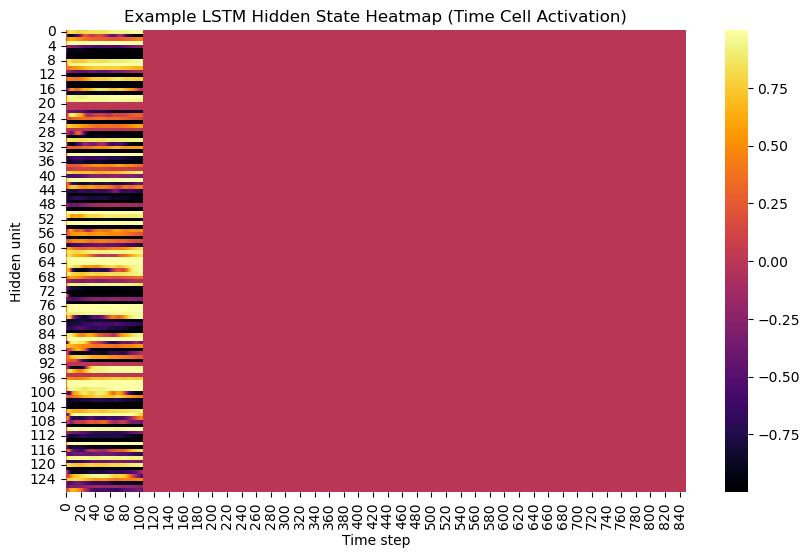

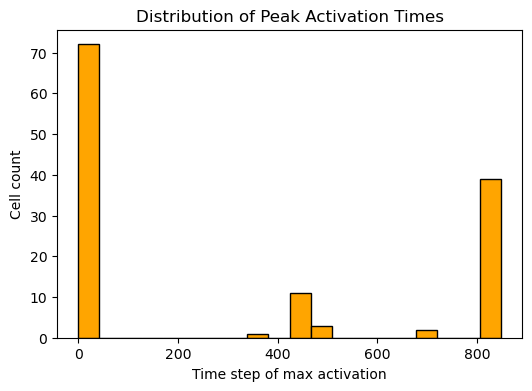

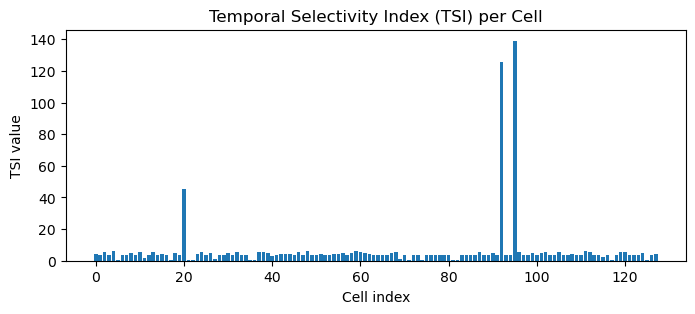

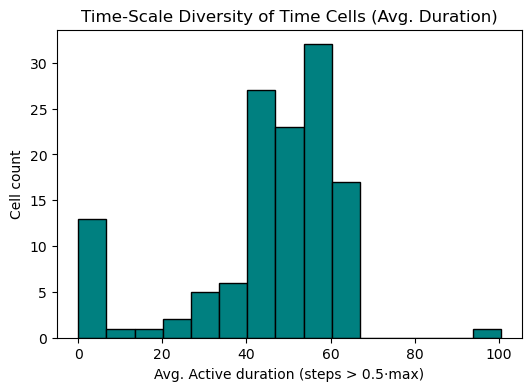

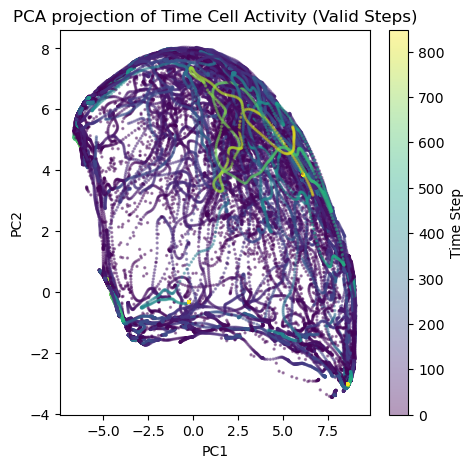

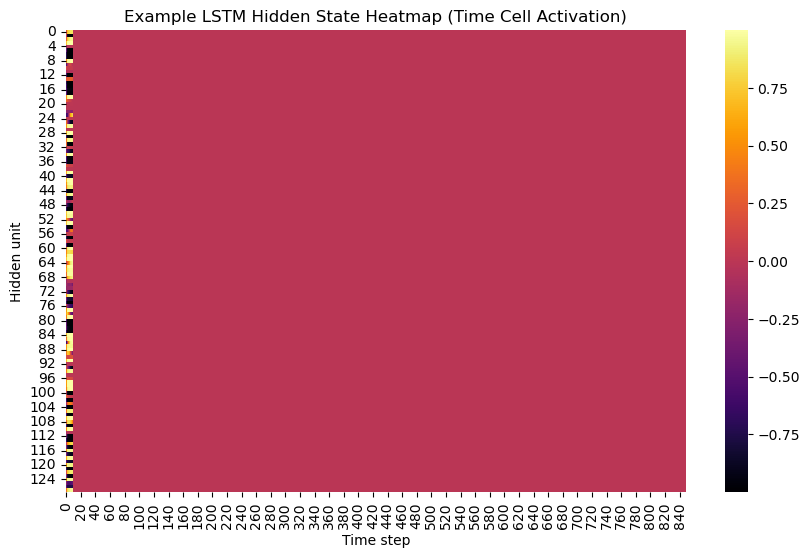

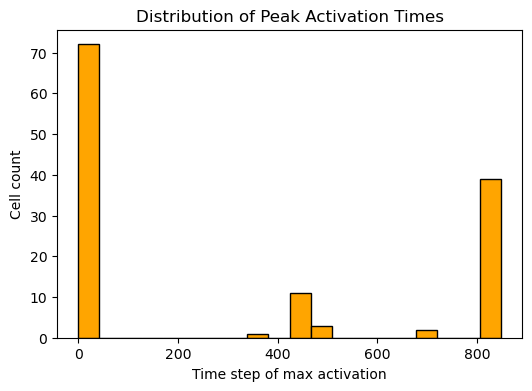

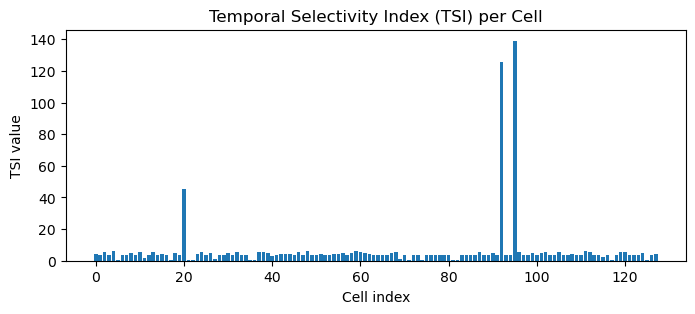

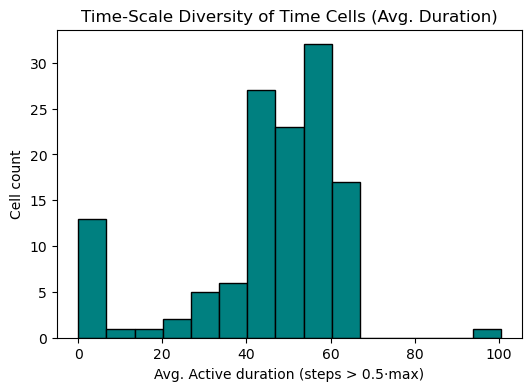

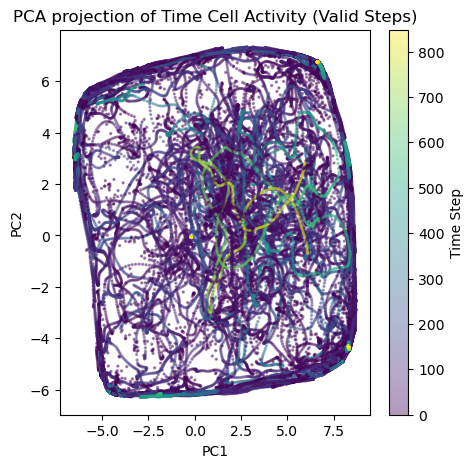

In [ ]:
# === 6.1) Generate time-cell mechanism plots (heatmap / peak / TSI / PCA) ===
# NOTE: Uses the trained model weights

model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.to(device).eval()

plotcell.analyze_time_cells(
    model=model,
    loader=loader,
    device=device,
    n_cells_to_plot=64,   # 原 max_cells_to_plot → n_cells_to_plot
    save_dir=SAVE_DIR
)

print("✅ Time-cell figures saved under:", SAVE_DIR)

res = plotcell.analyze_time_cells(
    model=model,
    loader=loader,
    device=device,
    n_cells_to_plot=64,
    save_dir=SAVE_DIR
)
print("pca3_explained_variance:", res.get("pca3_explained_variance"))


# Step 2: Core ablation #1 — Single-scale vs Multi-scale (Main table)
We implement a **multi-scale** variant by running multiple temporal resolutions (strides) through separate LSTMs and fusing their last hidden states.

We also provide a **single-scale** baseline (stride=1 only).

In this notebook, we map **temporal scale α ∈ [0,1]** to a stride list.
- α close to 0 → short timescale (fine resolution)
- α close to 1 → long timescale (coarse resolution)

For the paper, you can report α as normalized timescale weights (0–1).

In [ ]:
# === 7) Multi-scale model (temporal pyramid via multi-stride LSTMs) ===
# This keeps the same CNN encoder; only the temporal module changes.

class MultiScaleVisualTemporalNet(nn.Module):
    def __init__(self, feature_dim: int, hidden_dim: int, visual_dim: int, output_dim: int,
                 strides=(1,2,4)):
        super().__init__()
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.visual_dim = visual_dim
        self.output_dim = output_dim
        self.strides = tuple(strides)

        # Same CNN encoder as before
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, visual_dim), nn.ReLU()
        )

        # One LSTM per temporal scale (stride)
        self.lstms = nn.ModuleList([
            nn.LSTM(input_size=feature_dim + visual_dim,
                    hidden_size=hidden_dim,
                    num_layers=1,
                    batch_first=True)
            for _ in self.strides
        ])

        # Fusion (learnable) across scales
        self.fuse = nn.Linear(len(self.strides) * hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def _downsample(self, x, mask, stride: int):
        # x: [B,T,D], mask: [B,T]
        x_ds = x[:, ::stride, :]
        mask_ds = mask[:, ::stride]
        return x_ds, mask_ds

    def forward(self, feats, imgs, mask):
        B, T, _, H, W = imgs.shape
        v = self.cnn(imgs.view(B*T, 3, H, W)).view(B, T, self.visual_dim)
        x = torch.cat([feats, v], dim=-1)  # [B,T,D]

        last_states = []
        base_lstm_out = None

        for i, stride in enumerate(self.strides):
            x_s, m_s = self._downsample(x, mask, stride)
            lengths = m_s.sum(dim=1).long().cpu()
            packed = nn.utils.rnn.pack_padded_sequence(x_s, lengths, batch_first=True, enforce_sorted=False)
            packed_out, _ = self.lstms[i](packed)
            out_s, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x_s.shape[1])
            idx = (lengths - 1).clamp(min=0).to(out_s.device)
            last = out_s[torch.arange(B, device=out_s.device), idx]  # [B,H]
            last_states.append(last)

            # keep stride=1 outputs as "time-cell population" for analyses
            if stride == 1:
                # upsample back to T for compatibility (pad with zeros beyond valid length)
                base_lstm_out = torch.zeros(B, T, self.hidden_dim, device=out_s.device, dtype=out_s.dtype)
                base_lstm_out[:, :out_s.shape[1], :] = out_s

        fused = self.fuse(torch.cat(last_states, dim=-1))  # [B,H]
        pred = self.fc(fused)                              # [B,output_dim]
        return pred, base_lstm_out

def make_strides_from_alpha(alpha_list):
    """Map temporal scales α∈[0,1] to integer strides.
    A simple mapping: stride = 2**round(2*alpha) -> {1,2,4}.
    You can change this mapping later for your paper ablation.
    """
    strides = []
    for a in alpha_list:
        a = float(np.clip(a, 0.0, 1.0))
        s = int(2 ** int(round(2 * a)))  # 0->1, 0.5->2, 1->4
        strides.append(s)
    # unique & sorted
    return tuple(sorted(set(strides)))

print("✅ Multi-scale class ready.")


✅ Multi-scale class ready.


[single_scale] alpha_scales=[0.0] -> strides=(1,)


/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


Epoch 1/5 | loss=11.066179
✅ New best saved: ./eval_results_minimal/single_scale_best.pth (loss=11.066179)
Epoch 2/5 | loss=6.228047
✅ New best saved: ./eval_results_minimal/single_scale_best.pth (loss=6.228047)
Epoch 3/5 | loss=3.181153
✅ New best saved: ./eval_results_minimal/single_scale_best.pth (loss=3.181153)
Epoch 4/5 | loss=1.754319
✅ New best saved: ./eval_results_minimal/single_scale_best.pth (loss=1.754319)
Epoch 5/5 | loss=1.152188
✅ New best saved: ./eval_results_minimal/single_scale_best.pth (loss=1.152188)
Eval | MSE=16.105751 | R2=0.9587


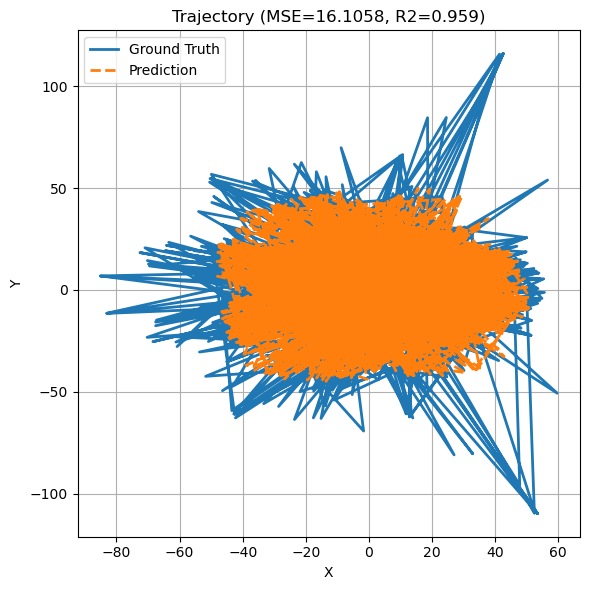

Saved plot: ./eval_results_minimal/single_scale_traj.png
[multi_scale] alpha_scales=[0.0, 0.5, 1.0] -> strides=(1, 2, 4)


/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


Epoch 1/5 | loss=8.077810
✅ New best saved: ./eval_results_minimal/multi_scale_best.pth (loss=8.077810)
Epoch 2/5 | loss=2.504424
✅ New best saved: ./eval_results_minimal/multi_scale_best.pth (loss=2.504424)
Epoch 3/5 | loss=1.170838
✅ New best saved: ./eval_results_minimal/multi_scale_best.pth (loss=1.170838)
Epoch 4/5 | loss=0.767964
✅ New best saved: ./eval_results_minimal/multi_scale_best.pth (loss=0.767964)
Epoch 5/5 | loss=0.570825
✅ New best saved: ./eval_results_minimal/multi_scale_best.pth (loss=0.570825)
Eval | MSE=7.163939 | R2=0.9815


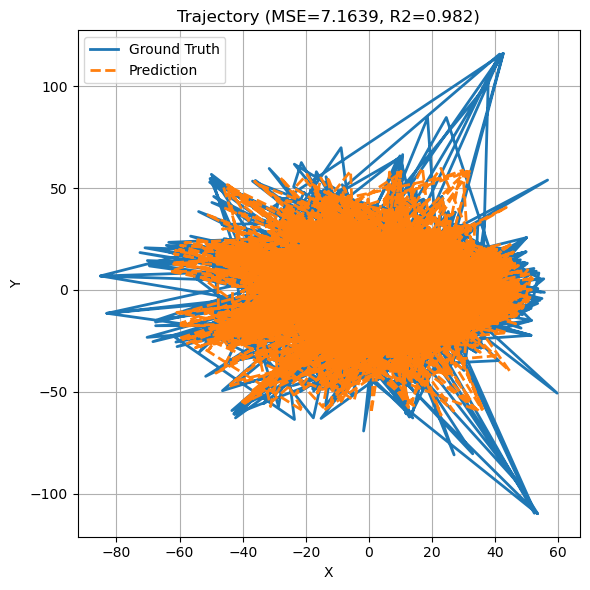

Saved plot: ./eval_results_minimal/multi_scale_traj.png
✅ Step 2 summary saved: ./eval_results_minimal/ablation_step2_single_vs_multi.csv


,MSE,R2,exp,alpha_scales,strides
0,16.105751,0.95865,single_scale,[0.0],"(1,)"
1,7.163939,0.98151,multi_scale,"[0.0, 0.5, 1.0]","(1, 2, 4)"


In [ ]:
# === 7.1) Train & evaluate helper for ablations (reuses earlier train/eval) ===
import pandas as pd

def train_and_eval(model, loader, device, epochs, lr, ckpt_path, prefix, save_dir):
    # train
    _ = train_minimal(model, loader, device, epochs=epochs, lr=lr, ckpt_path=ckpt_path)
    # eval
    preds, targets, metrics = evaluate_and_plot(model, loader, device, ckpt_path, save_dir=save_dir, prefix=prefix)
    return metrics

def run_multiscale_ablation(alpha_scales, exp_tag):
    strides = make_strides_from_alpha(alpha_scales)
    print(f"[{exp_tag}] alpha_scales={alpha_scales} -> strides={strides}")

    m = MultiScaleVisualTemporalNet(
        feature_dim=dataset.input_feature_dim,
        hidden_dim=HIDDEN_DIM,
        visual_dim=VISUAL_DIM,
        output_dim=dataset.target_dim,
        strides=strides
    ).to(device)

    ckpt_path = os.path.join(SAVE_DIR, f"{exp_tag}_best.pth")
    metrics = train_and_eval(
        m, loader, device,
        epochs=EPOCHS, lr=LR,
        ckpt_path=ckpt_path,
        prefix=exp_tag,
        save_dir=SAVE_DIR
    )
    metrics.update({"exp": exp_tag, "alpha_scales": str(alpha_scales), "strides": str(strides)})
    return metrics

# === Step 2 runs ===
# Single-scale baseline: alpha=[0.0] -> stride {1}
# Multi-scale (example): alpha=[0.0, 0.5, 1.0] -> strides {1,2,4}
results = []
results.append(run_multiscale_ablation([0.0], exp_tag="single_scale"))

# Multi-scale: (you can change alpha list later; both alpha and lambda should be in [0,1])
results.append(run_multiscale_ablation([0.0, 0.5, 1.0], exp_tag="multi_scale"))

df = pd.DataFrame(results)
out_csv = os.path.join(SAVE_DIR, "ablation_step2_single_vs_multi.csv")
df.to_csv(out_csv, index=False)
print("✅ Step 2 summary saved:", out_csv)
df


# Step 3: Core ablation #2 — No-fast / No-med / No-slow (standard output)
We reuse your `evalcell.evaluate_time_scales_and_extensions`.

Important: in your paper, temporal scale **α ∈ [0,1]**.
Here we map α thresholds to integer time-step thresholds using the current batch max length **T**:
- `fast_thr = round(α_fast * T)`
- `slow_thr = round(α_slow * T)`

Spatial scale **λ ∈ [0,1]** is handled in your separate scale-factor experiments (e.g., `ablation_scales.py`).

/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


Hidden states padded to (2892, 849, 128)
多尺度时间细胞评估完成。


/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


T_max=357, alpha_fast=0.2 -> fast_thr=71, alpha_slow=0.6 -> slow_thr=214
Fast=123, Medium=5, Slow=0


/media/zhen/Data/cogMap/biw/scale_ablation/model/evalcell.py:149: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
/media/zhen/Data/cogMap/biw/scale_ablation/model/evalcell.py:150: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.savefig(os.path.join(save_dir, "correlation_matrix.png"), dpi=200)


Saved evaluation summary to ./eval_results_minimal/timecell_eval_summary.csv
✅ Step 3 outputs (bar/csv/cross-traj) saved under: ./eval_results_minimal


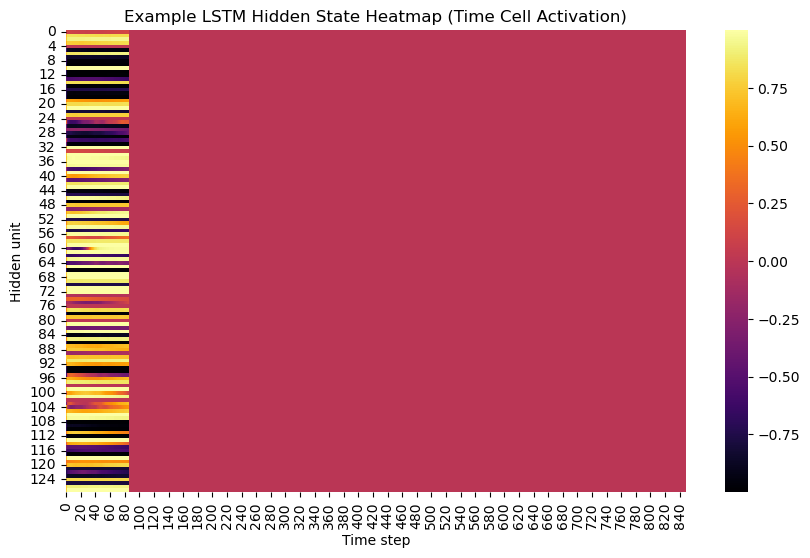

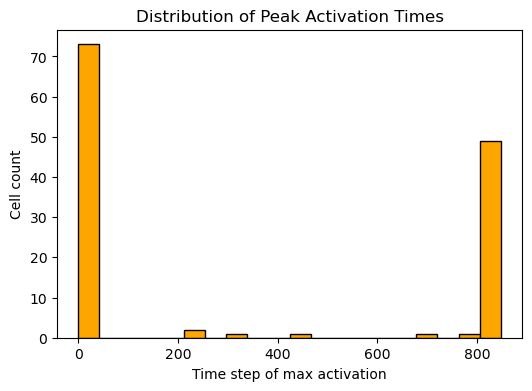

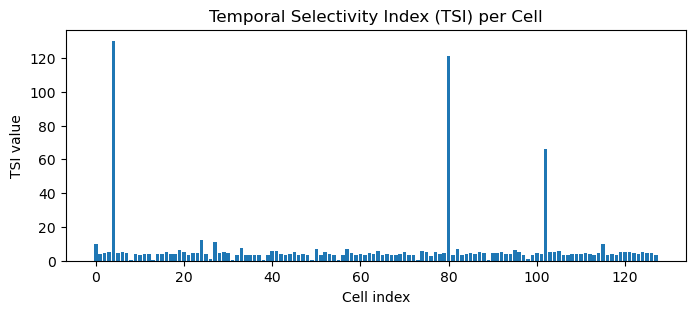

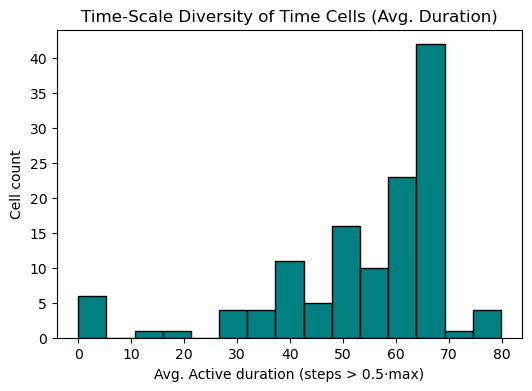

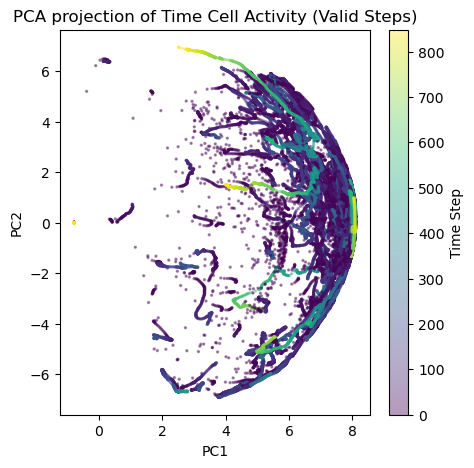

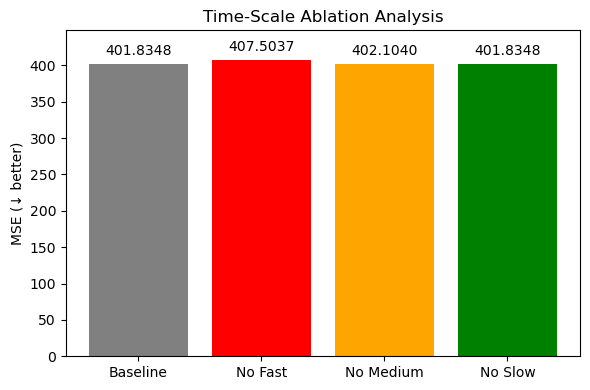

/media/zhen/Share/anaconda3/envs/cogmap_torchtem/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


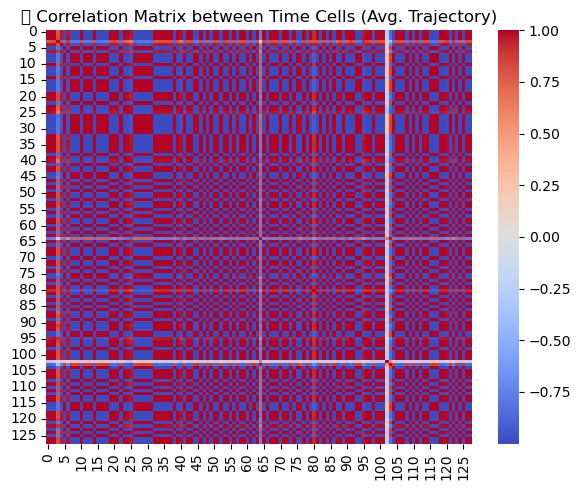

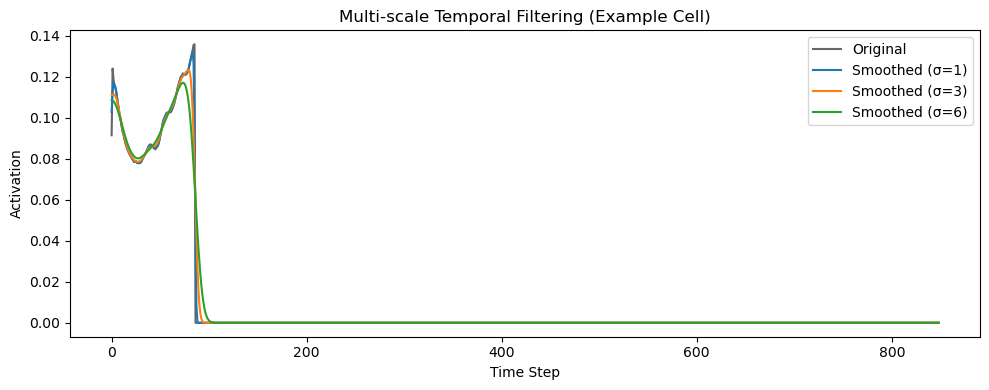

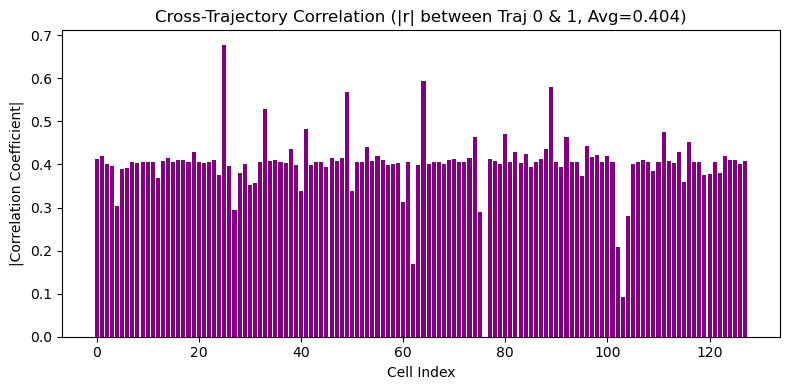

In [ ]:
# === 8) Step 3: No-fast / No-med / No-slow using alpha thresholds in [0,1] ===

MODEL_CKPT = os.path.join(SAVE_DIR, "multi_scale_best.pth")
assert os.path.exists(MODEL_CKPT), f"Missing checkpoint: {MODEL_CKPT}"

# Rebuild the same multi-scale model architecture for analysis
strides = make_strides_from_alpha([0.0, 0.5, 1.0])
ms_model = MultiScaleVisualTemporalNet(
    feature_dim=dataset.input_feature_dim,
    hidden_dim=HIDDEN_DIM,
    visual_dim=VISUAL_DIM,
    output_dim=dataset.target_dim,
    strides=strides
).to(device)

ms_model.load_state_dict(torch.load(MODEL_CKPT, map_location=device))
ms_model.eval()

# 1) 必须先得到 results（hidden_concat / cell_timescale）
#    注意：plotcell 的签名是 n_cells_to_plot，不是 max_cells_to_analyze
results = plotcell.analyze_time_cells(
    model=ms_model,
    loader=loader,
    device=device,
    n_cells_to_plot=64,
    save_dir=SAVE_DIR
)

# 2) alpha -> threshold
probe = next(iter(loader))
feats_p, imgs_p, targets_p, mask_p = probe
T_max = feats_p.shape[1]

alpha_fast = 0.2
alpha_slow = 0.6
fast_thr = max(1, int(round(alpha_fast * T_max)))
slow_thr = max(fast_thr + 1, int(round(alpha_slow * T_max)))

print(f"T_max={T_max}, alpha_fast={alpha_fast} -> fast_thr={fast_thr}, alpha_slow={alpha_slow} -> slow_thr={slow_thr}")

# 3) 调用 evalcell（按你 evalcell.py 的签名传参）
evalcell.evaluate_time_scales_and_extensions(
    model=ms_model,
    loader=loader,
    results=results,
    device=device,
    thresholds=(fast_thr, slow_thr),
    save_dir=SAVE_DIR
)

print("✅ Step 3 outputs (bar/csv/cross-traj) saved under:", SAVE_DIR)


/tmp/ipykernel_1237963/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


Padded trajectory data to shape: pos=(2892, 849, 3), yaw=(2892, 849)
Top 10 position-correlated cells: [ 75 110  52 101  28  85  77 112  60  70]
Top 10 yaw-correlated cells: []
Saved cell-trajectory correlation results to ./eval_results_minimal/timecell_traj_corr.csv
✅ Relation analysis saved under: ./eval_results_minimal


/media/zhen/Data/cogMap/biw/scale_ablation/model/evaltraj.py:204: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.tight_layout()
/media/zhen/Data/cogMap/biw/scale_ablation/model/evaltraj.py:205: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.savefig(os.path.join(save_dir, "cell_traj_corr_heatmap.png"), dpi=200)


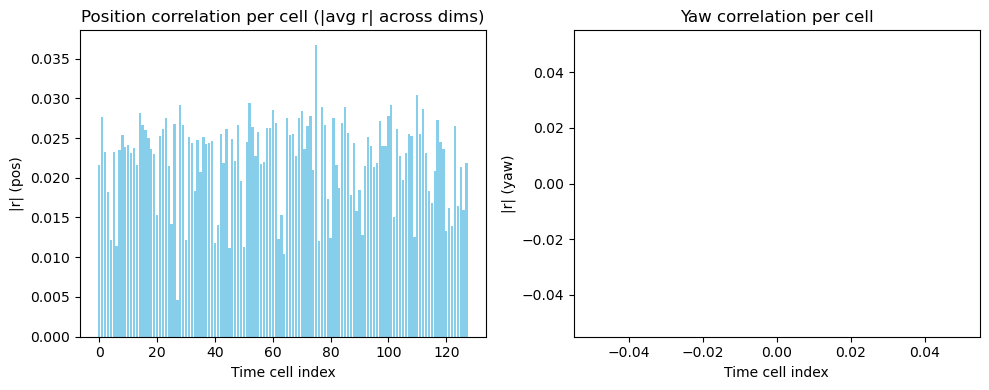

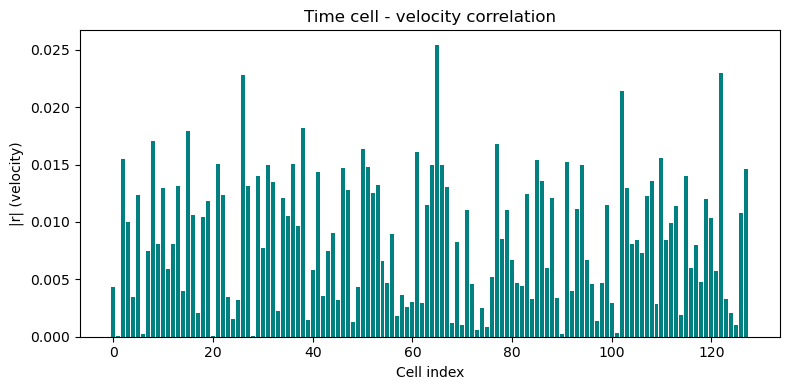

/media/zhen/Share/anaconda3/envs/cogmap_torchtem/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


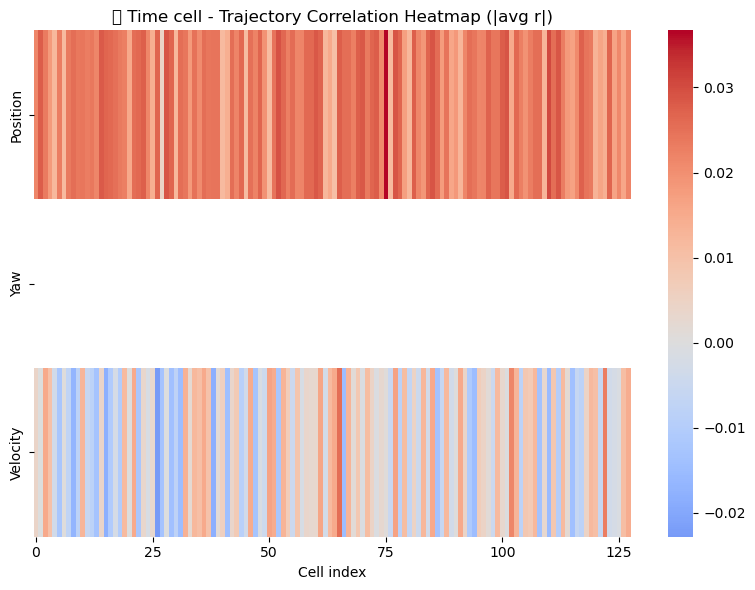

In [ ]:
# === 9) Cognitive relation analysis (pos/yaw/velocity correlations) ===
evaltraj.evaluate_timecell_trajectory_correlation(
    model=ms_model,
    loader=loader,
    results=results,
    device=device,
    save_dir=SAVE_DIR
)
print("✅ Relation analysis saved under:", SAVE_DIR)
